<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB
None
Personal Loan
0    4520
1     480
Name: count, dtype: int64


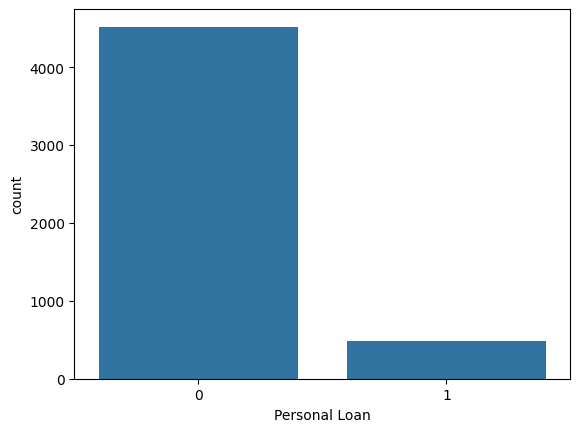

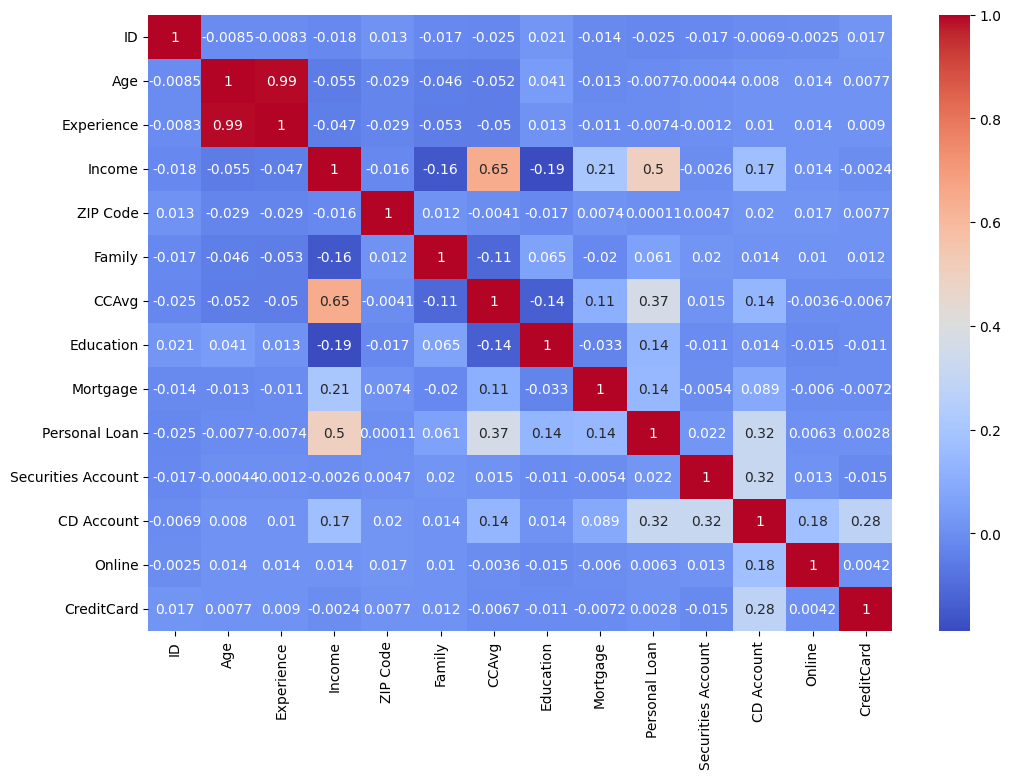

Train size: (4000, 12)
Test size: (1000, 12)
Accuracy: 0.954
Precision: 0.875
Recall: 0.5568181818181818


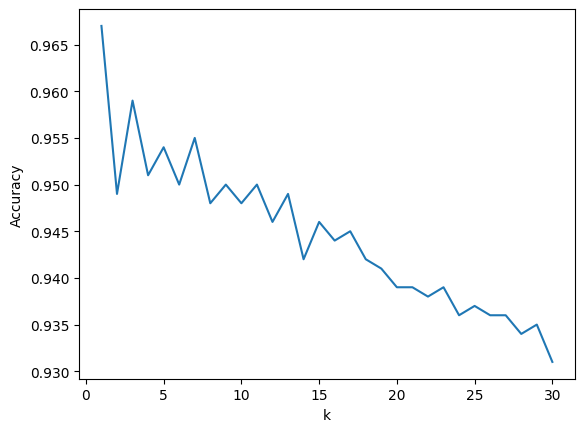

euclidean: 0.9540
manhattan: 0.9550
chebyshev: 0.9550
minkowski: 0.9540


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

loan_dataset = pd.read_csv('Bank_Personal_Loan_Modelling.csv')
print(loan_dataset.info())
print(loan_dataset['Personal Loan'].value_counts())

sns.countplot(x='Personal Loan', data=loan_dataset)
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(loan_dataset.corr(), annot=True, cmap='coolwarm')
plt.show()

X = loan_dataset.drop(['Personal Loan', 'ID'], axis=1)
y = loan_dataset['Personal Loan']

X = (X - X.min()) / (X.max() - X.min())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Khởi tạo mô hình với k=5
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

# Huấn luyện
knn.fit(X_train, y_train)

# Dự đoán trên test
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

k_range = range(1, 31)
acc_list = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc_list.append(accuracy_score(y_test, y_pred))

plt.plot(k_range, acc_list)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    print(f"{metric}: {acc:.4f}")